<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week10/day3-4/NN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with Neural Networks in TensorFlow

## Types of Classification

- **Binary Classification**: predicts one of 2 classes (e.g. spam vs not spam)
- **Multi-class Classification**: predicts one of 3+ mutually exclusive classes (e.g. classifying an image as cat, dog, or bird)
- **Multi-label Classification**: predicts multiple non-exclusive labels per sample (e.g. tagging a movie as both "comedy" and "romance")

This notebook builds a **binary classifier** on a circular dataset using TensorFlow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

In [2]:
from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1

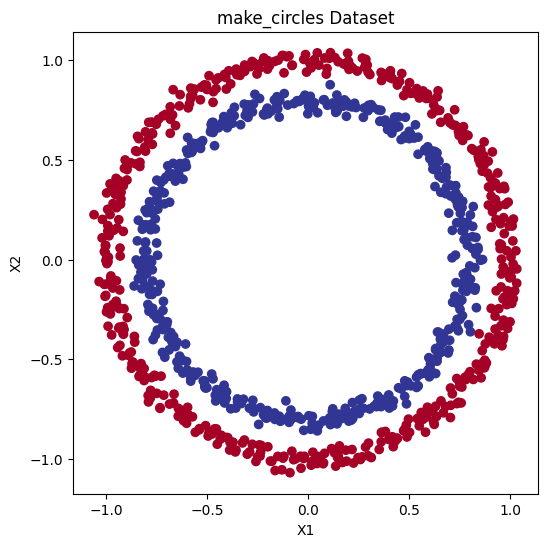

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("make_circles Dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [4]:
# Build a basic Sequential model with one dense layer
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile with Binary Crossentropy
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.SGD(),
                 metrics=['accuracy'])

# Train
history_1 = model_1.fit(X, y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4760 - loss: 4.0580   
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5020 - loss: 1.0035
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4960 - loss: 0.7229 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4950 - loss: 0.7029 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4920 - loss: 0.6971 


In [5]:
loss, accuracy = model_1.evaluate(X, y)
print(f"Model 1 — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5070 - loss: 0.6946  
Model 1 — Loss: 0.6946, Accuracy: 0.5070


In [6]:
# Add more layers and neurons, use Adam optimizer, train for more epochs
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=['accuracy'])

history_2 = model_2.fit(X, y, epochs=100, verbose=0)

In [7]:
loss, accuracy = model_2.evaluate(X, y)
print(f"Model 2 — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4840 - loss: 0.6933
Model 2 — Loss: 0.6933, Accuracy: 0.4840


In [8]:
def plot_decision_boundary(model, X, y):
    # Define the axis boundaries and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                          np.linspace(y_min, y_max, 100))

    # Stack grid points and get model predictions
    x_in = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(x_in)

    # Reshape predictions into probabilities/classes
    if len(y_pred[0]) > 1:
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        y_pred = np.round(y_pred).reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


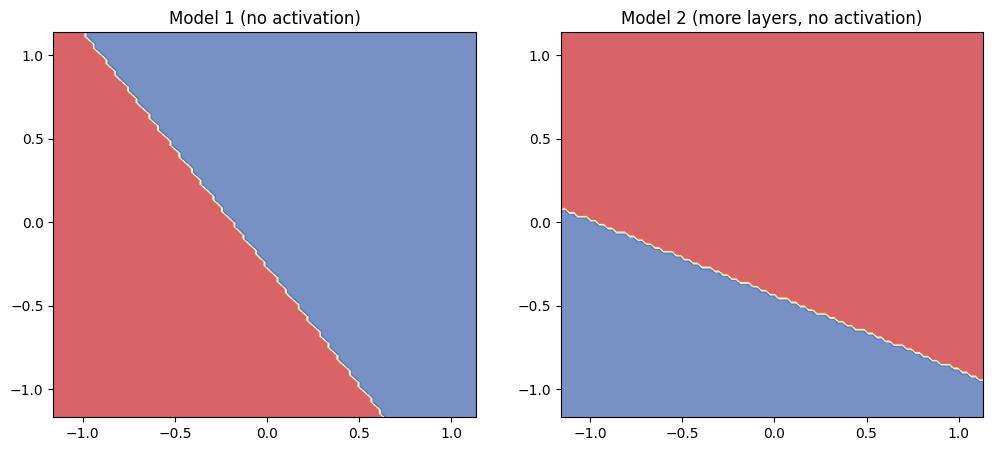

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Model 1 (no activation)")
plot_decision_boundary(model_1, X, y)

plt.subplot(1, 2, 2)
plt.title("Model 2 (more layers, no activation)")
plot_decision_boundary(model_2, X, y)

plt.show()

In [10]:
# Rebuild with ReLU on hidden layers and Sigmoid on output
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=['accuracy'])

history_3 = model_3.fit(X, y, epochs=100, verbose=0)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.3160  
Model 3 (with activation) — Loss: 0.3160, Accuracy: 0.9670
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


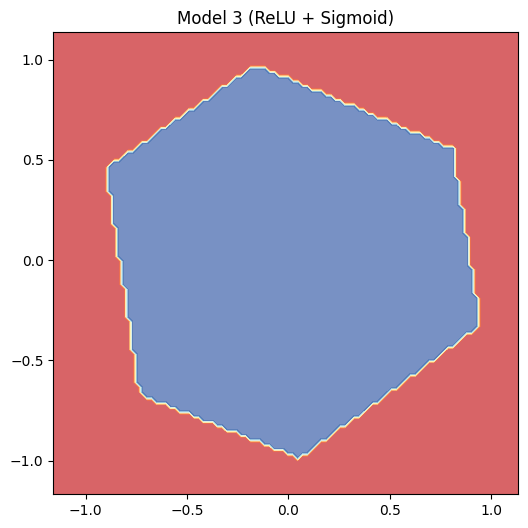

In [11]:
loss, accuracy = model_3.evaluate(X, y)
print(f"Model 3 (with activation) — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

plt.figure(figsize=(6, 6))
plt.title("Model 3 (ReLU + Sigmoid)")
plot_decision_boundary(model_3, X, y)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (800, 2), X_test shape: (200, 2)
y_train shape: (800,), y_test shape: (200,)


In [13]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=['accuracy'])

history_4 = model_4.fit(X_train, y_train, epochs=100, verbose=0)

In [14]:
train_loss, train_acc = model_4.evaluate(X_train, y_train)
test_loss, test_acc = model_4.evaluate(X_test, y_test)

print(f"Train — Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
print(f"Test  — Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9212 - loss: 0.4356  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8500 - loss: 0.4863  
Train — Loss: 0.4356, Accuracy: 0.9212
Test  — Loss: 0.4863, Accuracy: 0.8500


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


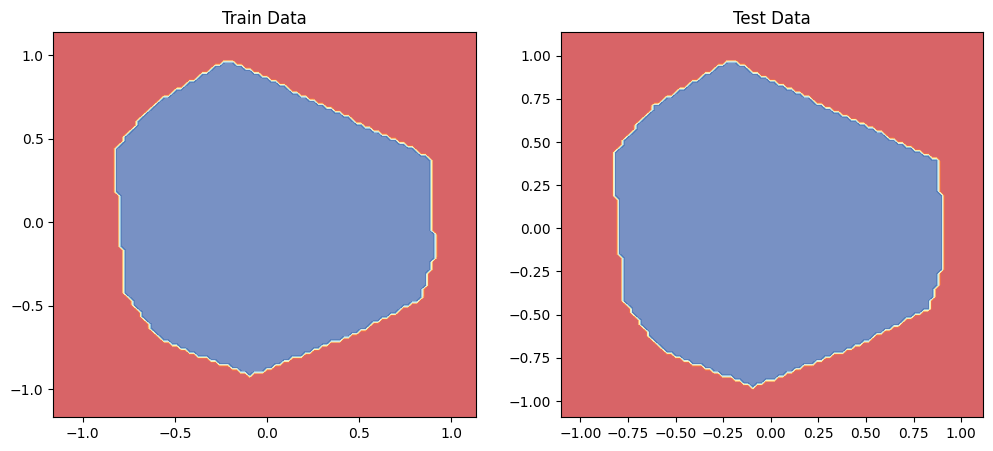

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Train Data")
plot_decision_boundary(model_4, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test Data")
plot_decision_boundary(model_4, X_test, y_test)

plt.show()

## Summary

- **Model 1 (single dense layer, no activation)**: essentially a linear classifier — could not separate the two concentric circles, accuracy near chance level.
- **Model 2 (more layers, no activation, Adam optimizer)**: adding layers without activation functions doesn't add expressive power — stacked linear layers collapse into a single linear function. Accuracy stayed low, even dipped slightly due to noisier optimization on more parameters.
- **Model 3 (ReLU + Sigmoid activations)**: introducing non-linear activations let the network learn a curved decision boundary that actually separates the circles. Accuracy jumped to **96.7%** (loss 0.316) — the single biggest improvement in the whole exercise.
- **Model 4 (train/test split)**: train accuracy was **92.1%** (loss 0.436), test accuracy was **85.0%** (loss 0.486). The ~7-point gap between train and test suggests mild overfitting, or simply variance from a small test set (200 samples) — worth re-running with a different `random_state` or more epochs/neurons to see if the gap is stable.

### Key lessons
- **Activation functions are essential** for non-linear decision boundaries — without them, no amount of extra layers or neurons helps.
- **Visualizing decision boundaries** made the linear-vs-non-linear distinction obvious in a way accuracy numbers alone didn't.
- **Train/test evaluation** matters: a model can look strong on training data but slip on unseen data, which is why splitting data and comparing both scores is a critical step before trusting a model.